## EDA & CLEANING

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [5]:
# Lectura
raw_dataset = pd.read_csv("online_retail.csv", parse_dates=["InvoiceDate"])
eda_dataset = raw_dataset.copy()
eda_dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(eda_dataset.shape)
eda_dataset.info()
eda_dataset.describe(include="all").T

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Quantity: Negative values | UnitPrice: Extra hight values | InvoiceNo: Cancelations

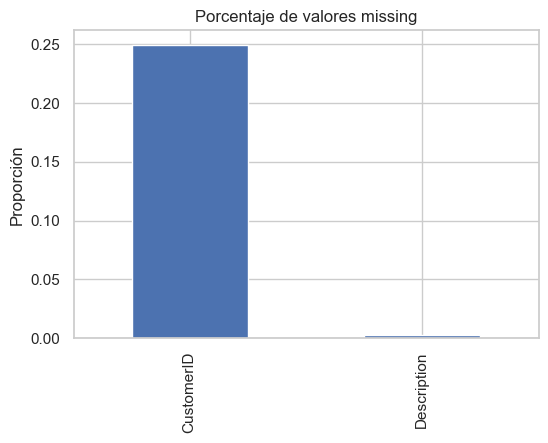

In [4]:
missing = (
    eda_dataset.isna()
      .mean()
      .sort_values(ascending=False)
)
missing
plt.figure(figsize=(6,4))
missing[missing > 0].plot(kind="bar")
plt.title("Porcentaje de valores missing")
plt.ylabel("Proporción")
plt.show()


In [5]:
# I decide to drop empty CustomerID values
eda_dataset = eda_dataset.dropna(subset=["CustomerID"])
eda_dataset["CustomerID"] = eda_dataset["CustomerID"].astype(int)


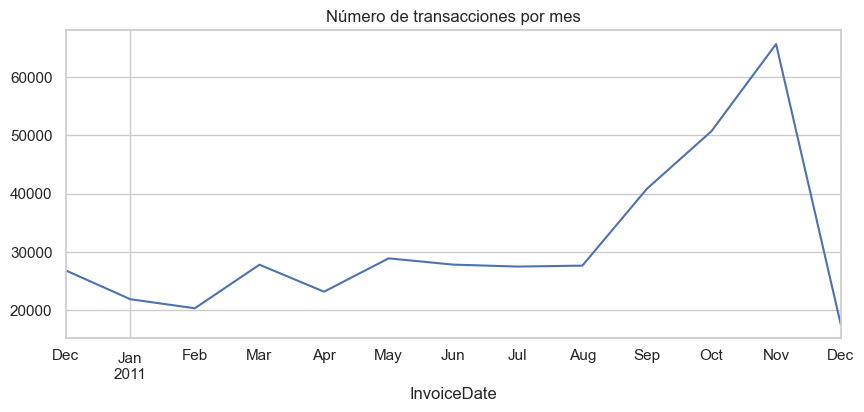

In [6]:
eda_dataset["InvoiceDate"].min(), eda_dataset["InvoiceDate"].max()
eda_dataset.set_index("InvoiceDate")["InvoiceNo"].resample("M").count().plot(
    figsize=(10,4),
    title="Número de transacciones por mes"
)
plt.show()


In [7]:
# Devoluciones
eda_dataset["is_cancelled"] = eda_dataset["InvoiceNo"].astype(str).str.startswith("C")
eda_dataset["is_cancelled"].value_counts(normalize=True)


is_cancelled
False    0.978111
True     0.021889
Name: proportion, dtype: float64

In [8]:
(eda_dataset["Quantity"] < 0).mean()


0.021888803403887137

In [9]:
eda_dataset["is_return"] = eda_dataset["Quantity"] < 0


In [10]:
(eda_dataset["UnitPrice"] <= 0).sum()


40

In [11]:
#Filtro para quitarme los precios negativos porque son errores
eda_dataset = eda_dataset[eda_dataset["UnitPrice"] > 0]


In [12]:
eda_dataset.duplicated().mean()


0.012844496778428128

In [13]:
eda_dataset = eda_dataset.drop_duplicates() #Eliminamos duplicados


In [14]:
# Creo una nueva variable
eda_dataset["TotalPrice"] = eda_dataset["Quantity"] * eda_dataset["UnitPrice"]


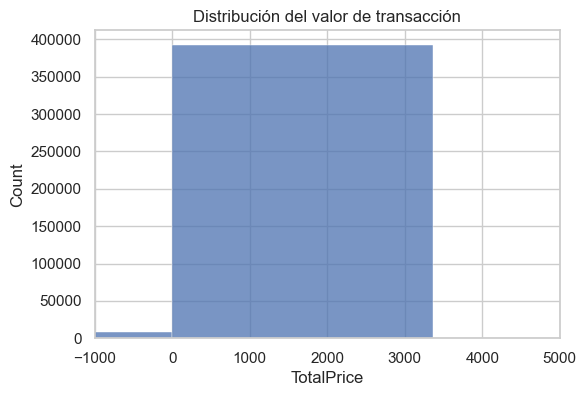

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(eda_dataset["TotalPrice"], bins=100)
plt.xlim(-1000, 5000)
plt.title("Distribución del valor de transacción")
plt.show()


“La distribución del valor de las transacciones presenta una fuerte asimetría positiva, con una alta concentración de valores pequeños y una cola larga asociada a compras de gran volumen. Para su análisis y modelado posterior se considerará el uso de transformaciones logarítmicas.”

In [17]:
# clean_path = "../data/processed/transactions_clean.csv"
eda_dataset.to_csv("eda_dataset.csv", index=False)
